In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [79]:
# Read in data


records = []

for csv_path in Path("outputs").rglob("metrics.csv"):
    parts = csv_path.parts
    df = pd.read_csv(csv_path)
    df["env"]    = parts[1]
    df["method"] = parts[2]
    df["seed"]   = parts[3]
    records.append(df)
    print(f"Loaded {len(df)} rows from {csv_path}")

print(f"Total dfs in records: {len(records)}")
all_runs = pd.concat(records, ignore_index=True)
print(all_runs.shape)

Loaded 1000 rows from outputs/CartPole-v1/vectr_std1.0/seed3_job3868997_20260422_002800/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/vectr_std1.0/seed4_job3868953_20260422_002800/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/vectr_std1.0/seed2_job3868996_20260422_002800/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/vectr_std1.0/seed0_job3868994_20260422_002800/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/vectr_std1.0/seed1_job3868995_20260422_002800/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/identity/seed4_job3868958_20260422_002749/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/identity/seed2_job3868956_20260422_002749/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/identity/seed0_job3868954_20260422_002748/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/identity/seed3_job3868957_20260422_002749/metrics.csv
Loaded 1000 rows from outputs/CartPole-v1/identity/seed1_job3868955_20260422_002749/metrics.csv
Loaded 1000 rows fro

In [80]:
# Use this to pick instances

# Order: baseline first, then scaling variants, then your main methods
METHOD_ORDER = [
    "identity",
    "scale_0.5", "scale_1.0", "scale_2.0", "scale_5.0",
    "zscore_std1.0", "minmax", "tanh_gain1.0",
    "vectr_std1.0",
]

VECTR_COMPARE = [
    "identity","vectr_std1.0",
]

SCALE_COMPARE = ["identity","scale_0.5", "scale_1.0", "scale_2.0", "scale_5.0"]

TRANS_COMPARE = ["identity","zscore_std1.0", "minmax", "tanh_gain1.0"]

COLORS = {
    "identity":     "#888888",   # gray — baseline
    "scale_0.5":    "#c6dbef",
    "scale_1.0":    "#9ecae1",
    "scale_2.0":    "#4292c6",
    "scale_5.0":    "#084594",
    "zscore_std1.0":"#a1d99b",
    "minmax":       "#41ab5d",
    "tanh_gain1.0": "#e6550d",
    "vectr_std1.0": "#d62728",   # red — your main contribution
}

def format_metric_name(metric):
    mapping = {
        # Performance
        "episode_return_mean": "Average Episode Return",
        "episode_length_mean": "Average Episode Length",

        # Reward stats
        "raw_reward_mean": "Raw Reward Mean",
        "raw_reward_var": "Raw Reward Variance",
        "transformed_reward_mean": "Transformed Reward Mean",
        "transformed_reward_var": "Transformed Reward Variance",

        # Advantage stats
        "advantage_mean": "Advantage Mean",
        "advantage_var": "Advantage Variance",

        # Optimization / gradients
        "grad_norm": "Gradient Norm",
        "policy_loss": "Policy Loss",
        "value_loss": "Value Loss",
        "entropy": "Policy Entropy",

        # Stability
        "approx_kl": "Approximate KL Divergence",
        "clipfrac": "Clipping Fraction",

        # Bookkeeping (less likely to plot, but included)
        "global_step": "Environment Steps",
        "update": "Training Updates",
    }
    
    return mapping.get(metric, metric.replace("_", " ").title())

# Build concise name: env__metric_shortname__methods_shortname.png
METRIC_SHORT = {
    "episode_return_mean": "return",
    "eval_return_mean": "eval_return",
    "advantage_var": "adv_var",
    "approx_kl": "kl",
    "grad_norm": "grad_norm",
    "clipfrac": "clipfrac",
    "transformed_reward_var": "reward_var",
    "entropy": "entropy",
}

METHOD_SHORT = {
    ("identity", "vectr_std1.0"): "vectr_vs_baseline",
    ("identity", "zscore_std1.0", "minmax", "tanh_gain1.0"): "transforms_vs_baseline",
    ("identity", "scale_0.5", "scale_1.0", "scale_2.0", "scale_5.0"): "scale_ablation",
    ("identity", "scale_0.5", "scale_1.0", "scale_2.0", "scale_5.0", "zscore_std1.0", "minmax", "tanh_gain1.0", "vectr_std1.0"): "all_methods",
}

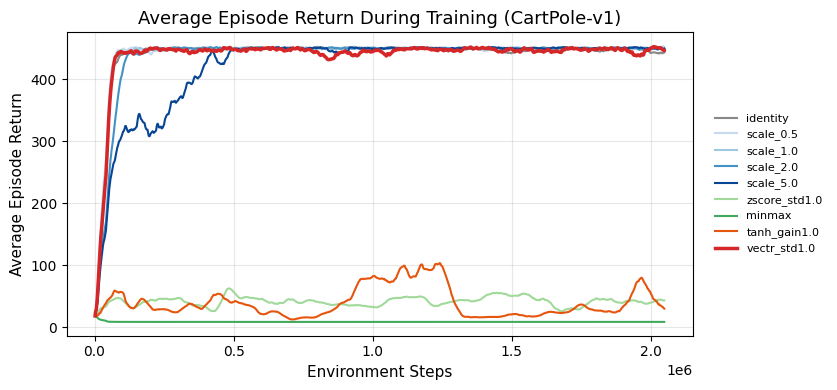

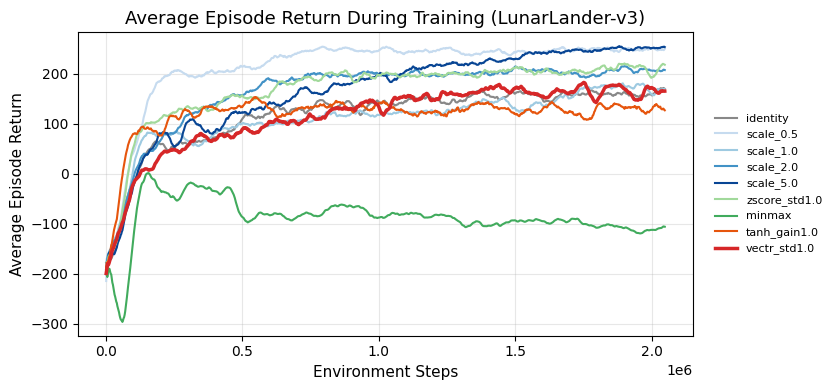

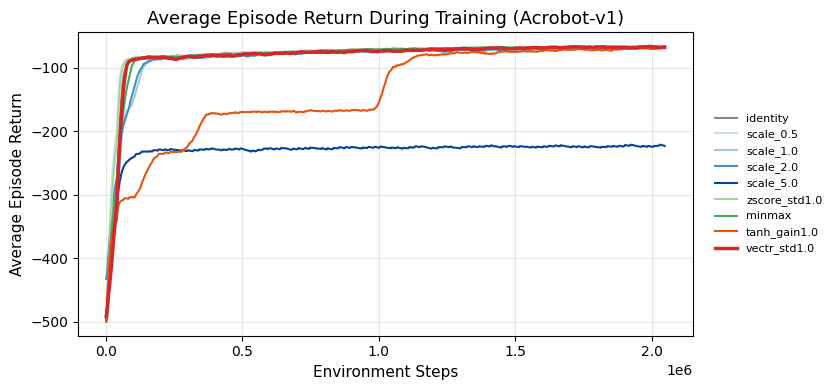

In [81]:
def plot_learning_curves(env_name, metric="episode_return_mean", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = METHOD_ORDER
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

In [82]:
def final_performance_table(metric="episode_return_mean", last_n=50):
    rows = []
    for (env, method), grp in all_runs.groupby(["env", "method"]):
        # For each seed, take the mean of its last N rows
        seed_finals = (grp.groupby("seed")
                          .apply(lambda x: x.nlargest(last_n, "global_step")[metric].mean()))
        rows.append({
            "env": env,
            "method": method,
            "mean": seed_finals.mean(),
            "std": seed_finals.std(),
        })
    
    table = pd.DataFrame(rows)
    table["summary"] = table.apply(lambda r: f"{r['mean']:.1f} ± {r['std']:.1f}", axis=1)
    
    pivot = table.pivot(index="method", columns="env", values="summary")
    # Reorder rows
    pivot = pivot.reindex([m for m in METHOD_ORDER if m in pivot.index])
    return pivot

final_performance_table()

env,Acrobot-v1,CartPole-v1,LunarLander-v3
method,,,
identity,-68.5 ± 1.6,444.0 ± 14.4,164.0 ± 56.5
scale_0.5,-67.2 ± 2.0,450.6 ± 1.0,248.2 ± 21.9
scale_1.0,-68.2 ± 1.1,451.0 ± 1.1,165.9 ± 83.9
scale_2.0,-68.7 ± 1.0,448.9 ± 0.9,206.8 ± 60.5
scale_5.0,-223.3 ± 206.6,450.0 ± 1.2,252.0 ± 9.0
zscore_std1.0,-66.8 ± 0.6,41.6 ± 35.3,208.0 ± 68.7
minmax,-67.5 ± 0.5,8.7 ± 0.0,-110.6 ± 26.6
tanh_gain1.0,-136.3 ± 148.9,45.7 ± 51.4,128.7 ± 33.5
vectr_std1.0,-67.7 ± 2.0,447.9 ± 5.5,168.0 ± 102.3


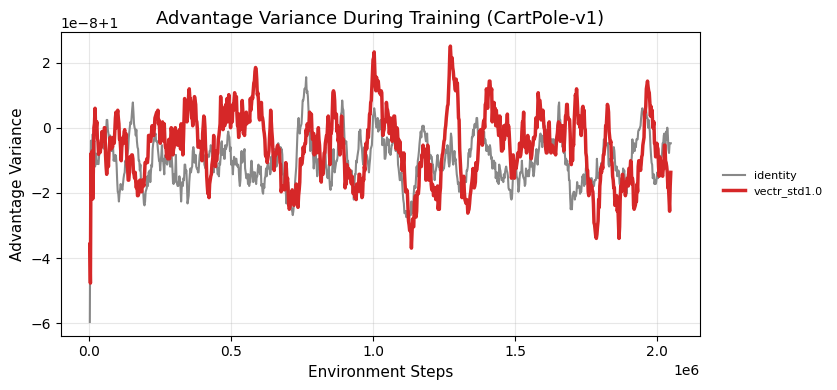

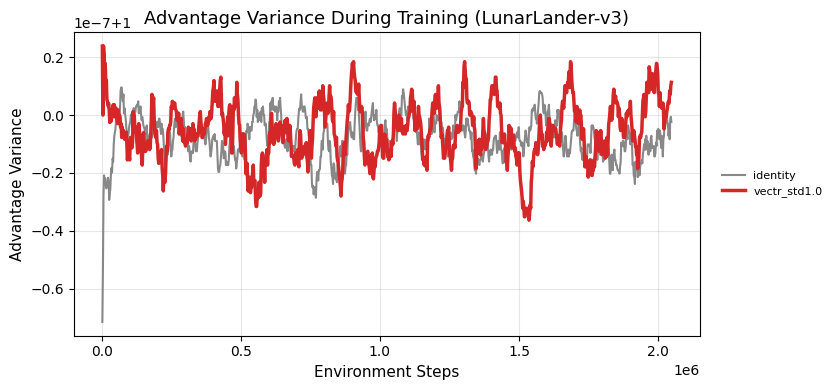

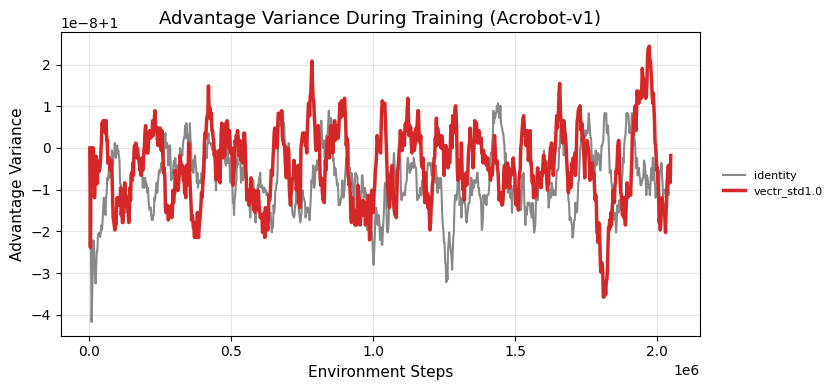

In [83]:
def plot_learning_curves(env_name, metric="advantage_var", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = VECTR_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

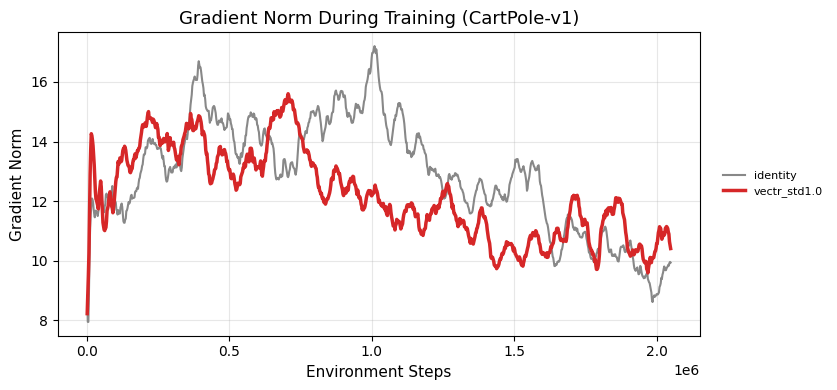

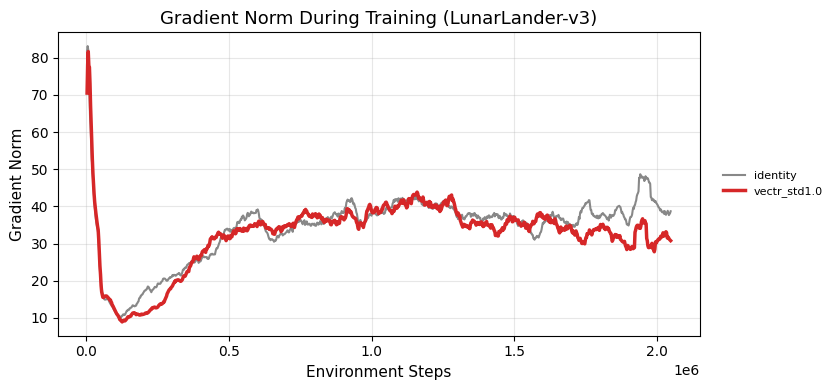

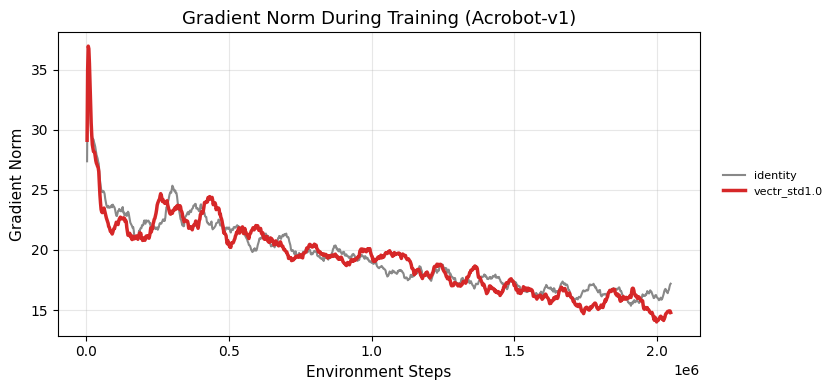

In [84]:
def plot_learning_curves(env_name, metric="grad_norm", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = VECTR_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

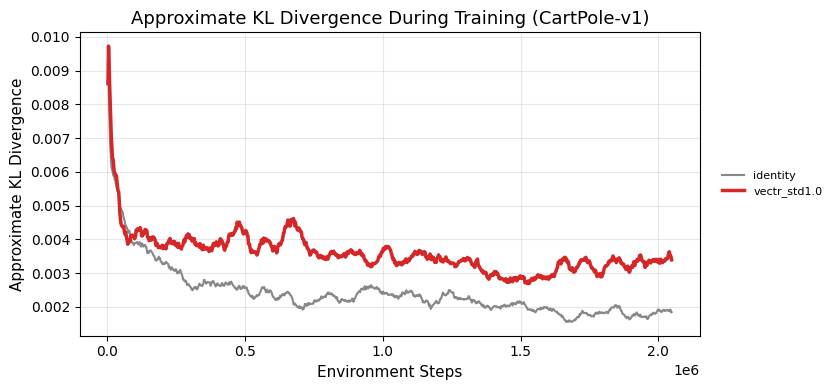

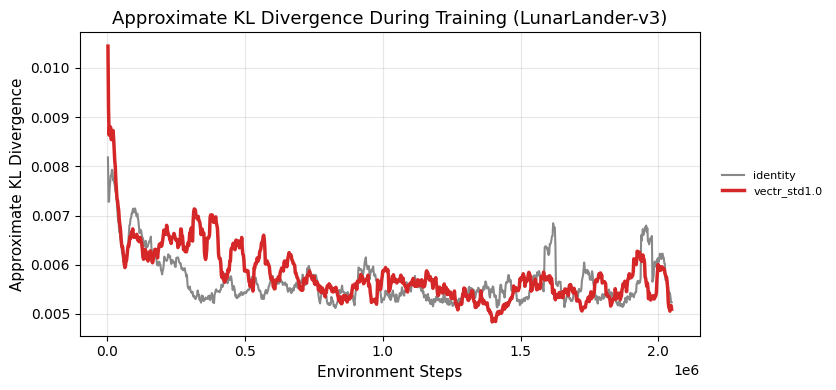

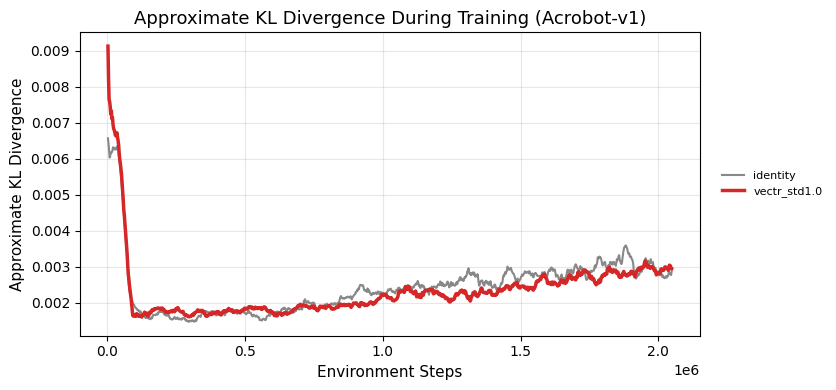

In [85]:
def plot_learning_curves(env_name, metric="approx_kl", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = VECTR_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

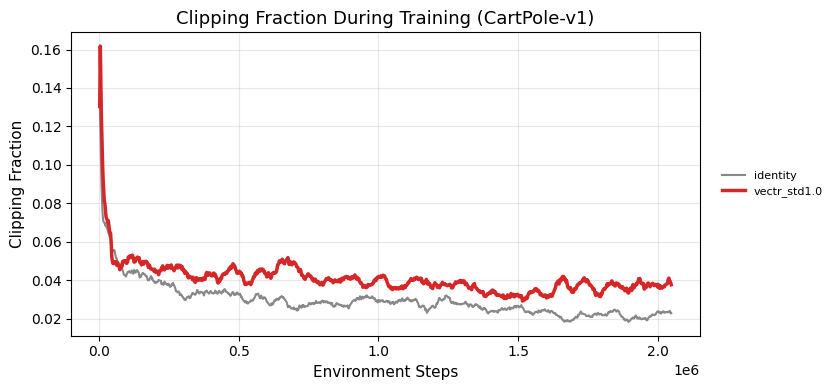

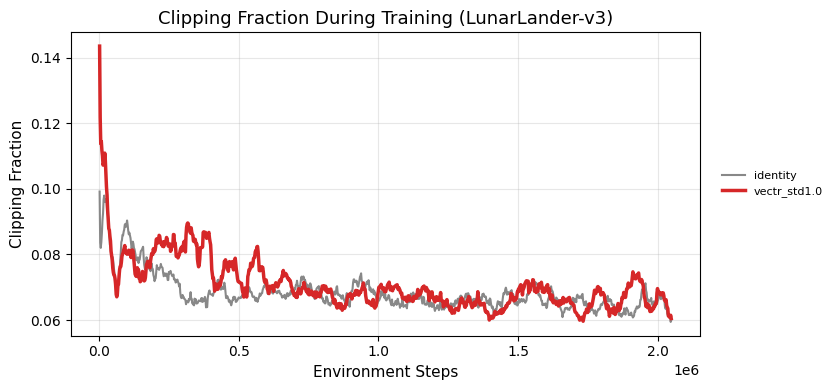

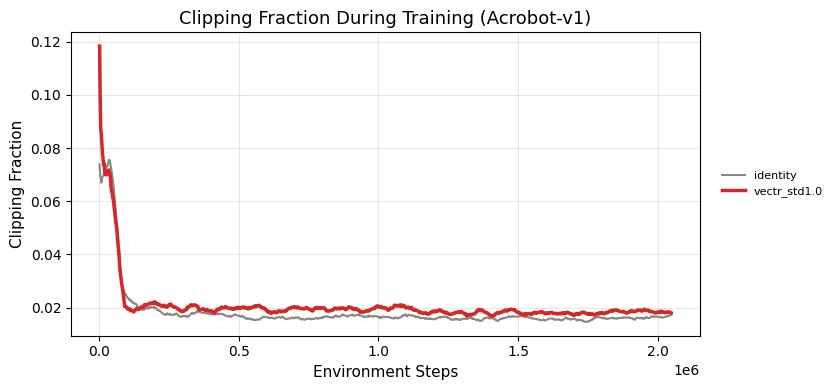

In [86]:
def plot_learning_curves(env_name, metric="clipfrac", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = VECTR_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()

for env in all_runs["env"].unique():
    plot_learning_curves(env)

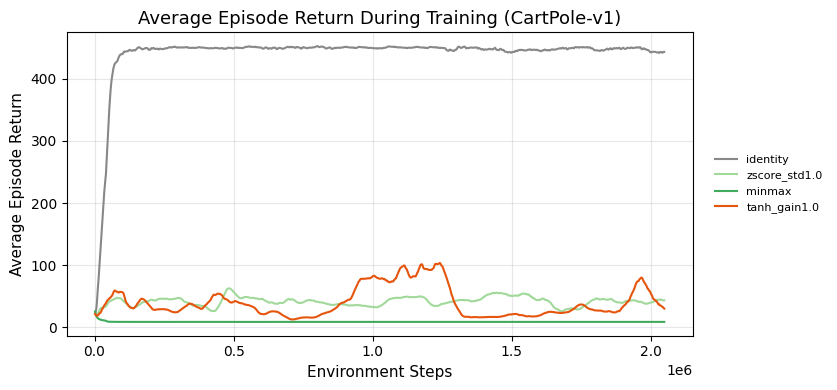

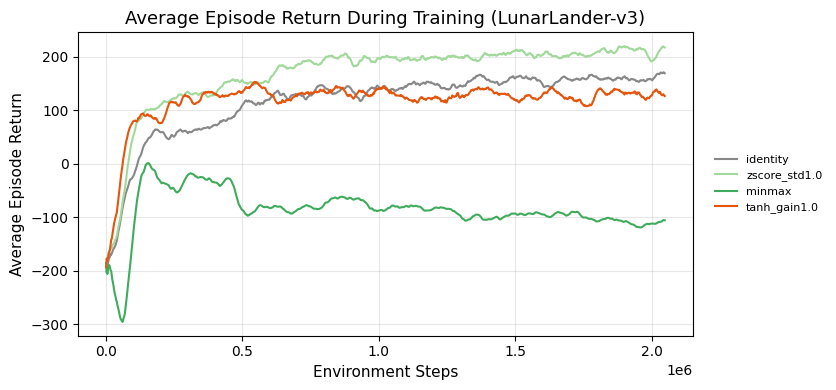

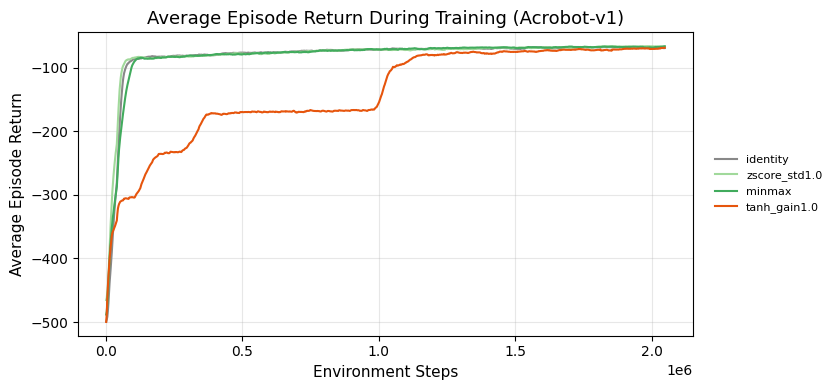

In [87]:
def plot_learning_curves(env_name, metric="episode_return_mean", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = TRANS_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

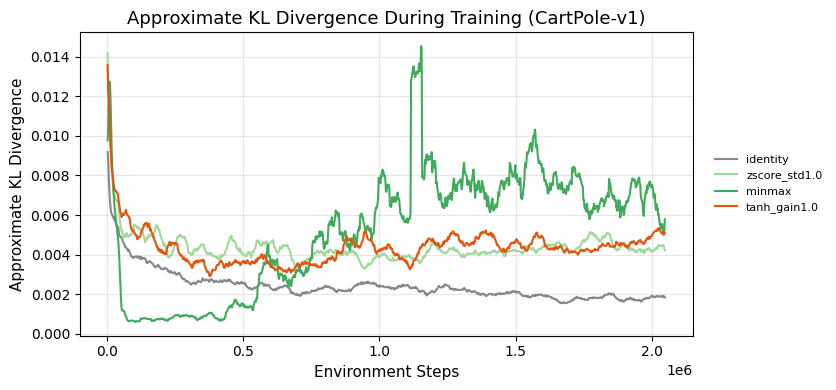

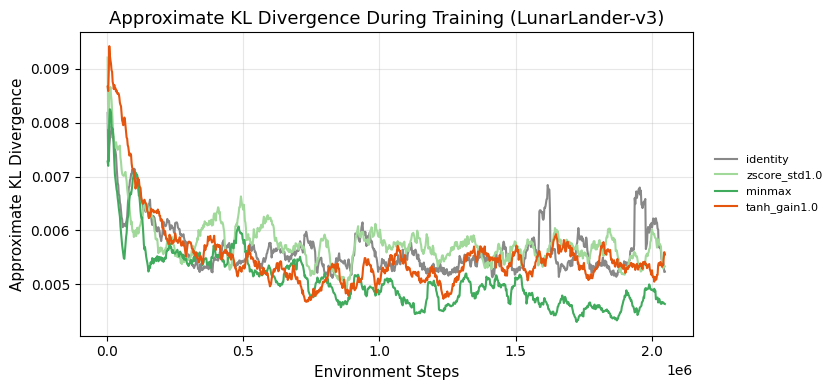

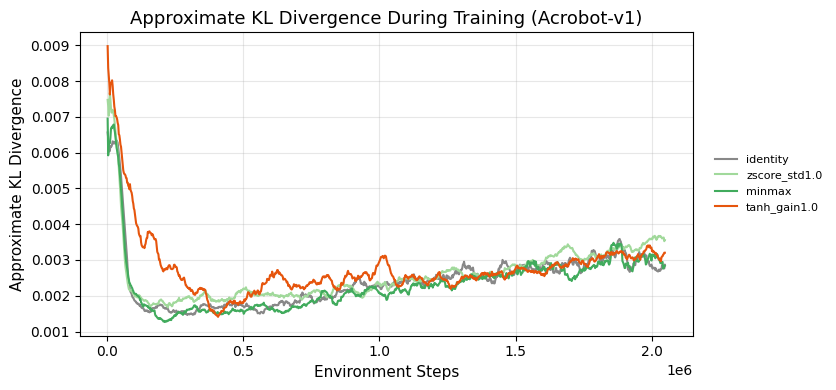

In [88]:
def plot_learning_curves(env_name, metric="approx_kl", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = TRANS_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

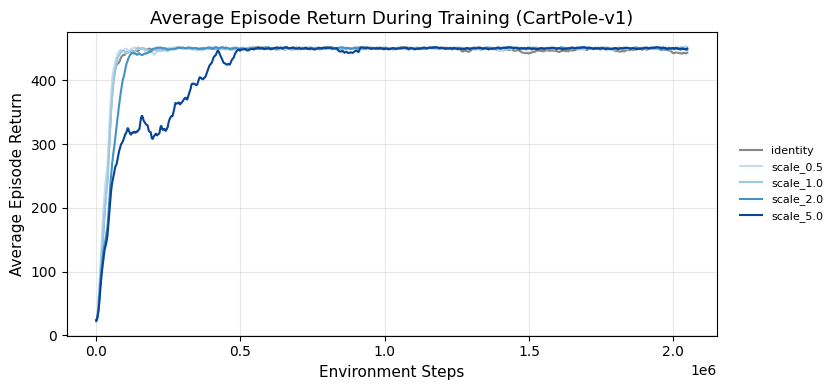

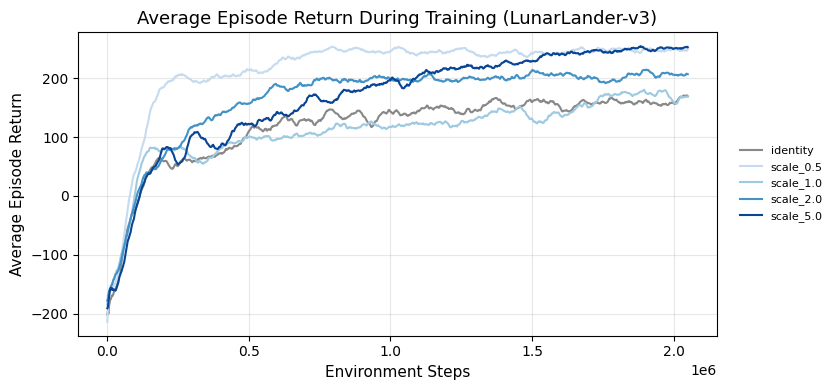

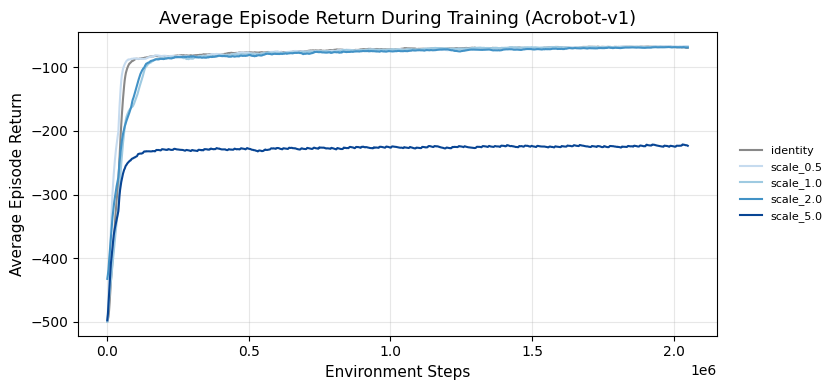

In [89]:
def plot_learning_curves(env_name, metric="episode_return_mean", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = SCALE_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

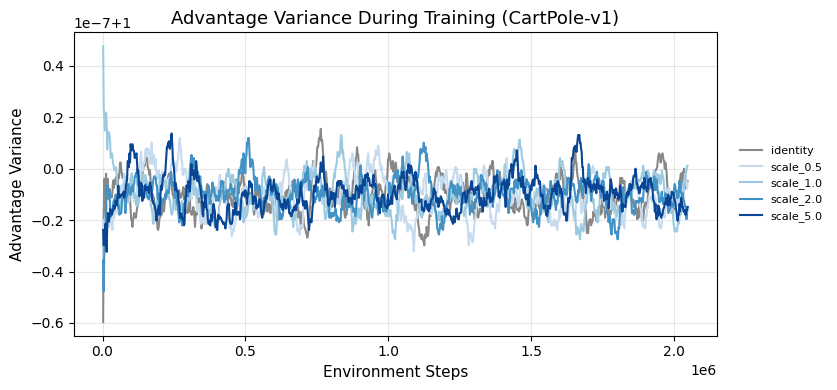

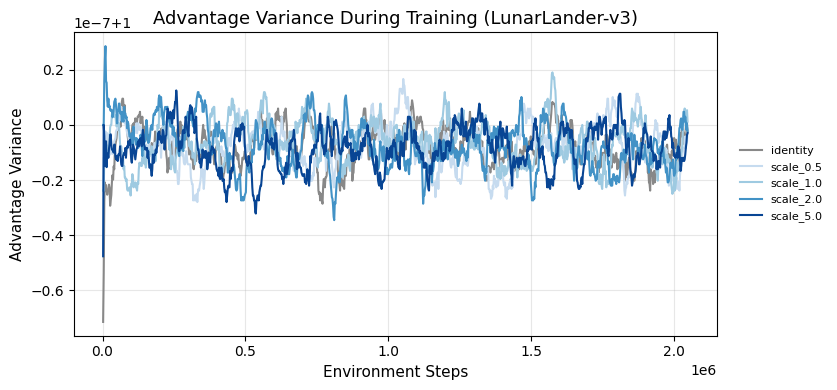

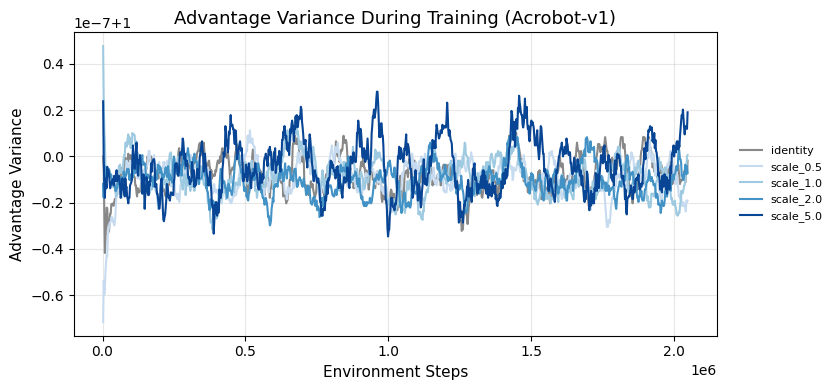

In [90]:
def plot_learning_curves(env_name, metric="advantage_var", smooth=20):
    subset = all_runs[all_runs["env"] == env_name].copy()
    
    fig, ax = plt.subplots(figsize=(10, 4))

    COMPARE = SCALE_COMPARE
    
    for method in COMPARE:
        grp = subset[subset["method"] == method]
        if grp.empty:
            continue
        
        agg = (grp.groupby("global_step")[metric]
                  .mean()
                  .sort_index())
        
        m = agg.rolling(smooth, min_periods=1).mean()
        
        lw = 2.5 if method == "vectr_std1.0" else 1.5
        ax.plot(
            agg.index, m,
            label=method,
            color=COLORS[method],
            linewidth=lw
        )
    
    # Clean, publication-style labels
    metric_name = format_metric_name(metric)
    
    ax.set_title(f"{metric_name} During Training ({env_name})", fontsize=13)
    ax.set_xlabel("Environment Steps", fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    # Legend outside
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=8,
        frameon=False
    )
    
    # Light grid for readability (paper-friendly)
    ax.grid(alpha=0.3)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    metric_short = METRIC_SHORT.get(metric, metric)
    method_key = tuple(COMPARE)
    method_short = METHOD_SHORT.get(method_key, "_vs_".join(COMPARE))
    filename = f"{env_name}__{metric_short}__{method_short}.png"
    plt.savefig(figures_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()


for env in all_runs["env"].unique():
    plot_learning_curves(env)

In [93]:
import os
print('\n'.join(sorted(os.listdir('figures'))))

Acrobot-v1__adv_var__scale_ablation.png
Acrobot-v1__adv_var__vectr_vs_baseline.png
Acrobot-v1__clipfrac__vectr_vs_baseline.png
Acrobot-v1__grad_norm__vectr_vs_baseline.png
Acrobot-v1__kl__transforms_vs_baseline.png
Acrobot-v1__kl__vectr_vs_baseline.png
Acrobot-v1__return__all_methods.png
Acrobot-v1__return__scale_ablation.png
Acrobot-v1__return__transforms_vs_baseline.png
CartPole-v1__adv_var__scale_ablation.png
CartPole-v1__adv_var__vectr_vs_baseline.png
CartPole-v1__clipfrac__vectr_vs_baseline.png
CartPole-v1__grad_norm__vectr_vs_baseline.png
CartPole-v1__kl__transforms_vs_baseline.png
CartPole-v1__kl__vectr_vs_baseline.png
CartPole-v1__return__all_methods.png
CartPole-v1__return__scale_ablation.png
CartPole-v1__return__transforms_vs_baseline.png
LunarLander-v3__adv_var__scale_ablation.png
LunarLander-v3__adv_var__vectr_vs_baseline.png
LunarLander-v3__clipfrac__vectr_vs_baseline.png
LunarLander-v3__grad_norm__vectr_vs_baseline.png
LunarLander-v3__kl__transforms_vs_baseline.png
LunarL